In [802]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

### Caricamento Dati

In [803]:
CSV_files = {
    "customers":           r"output/customers.csv",
    "geolocation_dataset": r"output/geolocation_dataset.csv",
    "order_items":         r"output/orders_items.csv",
    "order_payments":      r"output/order_payments.csv",
    "order_review":        r"output/order_review.csv",
    "order_dataset":       r"output/order_dataset.csv",
    "list_product":        r"output/list_product.csv",
    "list_seller":         r"output/list_seller.csv",
    "og_product_list":     r"dataset/olist_products_dataset.csv"
}

dataframes = {name: pd.read_csv(path) for name, path in CSV_files.items()}

df_customers           = dataframes["customers"]
df_orders_items        = dataframes["order_items"]
df_order_payments      = dataframes["order_payments"]
df_order_review        = dataframes["order_review"]
df_order_dataset       = dataframes["order_dataset"]
df_list_seller         = dataframes["list_seller"]
df_geolocation_dataset = dataframes["geolocation_dataset"]
df_list_product          = dataframes["og_product_list"]

### CREAZIONE DI DATAFRAME GLOBAL

#### Dataframe global (aggregazione per ordini)

In [804]:
#importiamo le colonne che ci servono da og_product_list
df_list_product['weight']=df_list_product['product_weight_g']/1000
df_list_product['height']=df_list_product['product_height_cm']/100
df_list_product['width']=df_list_product['product_width_cm']/100
df_list_product['length']=df_list_product['product_length_cm']/100
df_list_product['volume']=(df_list_product['height']*df_list_product['width']*df_list_product['length'])

# 1. Merge fra seller e geolocation
df_seller_geo = df_list_seller.merge(
    df_geolocation_dataset,
    on='geolocation_zip_code_prefix',
    how='left'
)

#rename lat, lng, city, state
df_seller_geo=df_seller_geo.rename(columns={'geolocation_lat':'seller_lat','geolocation_lng':'seller_lng','geolocation_city':'seller_city','geolocation_state':'seller_state'})

# 2. Merge fra customers e geolocation
df_customer_geo = df_customers.merge(
    df_geolocation_dataset,
    on='geolocation_zip_code_prefix', 
    how='left'
)

#rename lat, lng, city, state
df_customer_geo=df_customer_geo.rename(columns={'geolocation_lat':'customer_lat','geolocation_lng':'customer_lng','geolocation_city':'customer_city','geolocation_state':'customer_state'})

# 3. Aggregazione order_items per order_id
agg_orders_items = (df_orders_items.groupby('order_id', as_index = False).agg(
    total_items=('order_item_id', 'count'),       # numero di prodotti venduti
    total_price=('eur_price', 'sum'),                 # somma prezzi
    freight_total=('eur_freight_value', 'sum'),       # somma costi spedizione
    freight_avg=('eur_freight_value', 'mean'),        # media costi spedizione
    first_shipping_limit=('shipping_limit_date', 'min')  # primo limite spedizione
)
)

# 4. Aggregazione order_payments per order_id
agg_order_payments = (
    df_order_payments
    .groupby('order_id', as_index=False)
    .agg(
        total_payment_value= ('eur_total_payment_value', 'sum'),
        payment_installments= ('payment_installments', 'max'),
        payment_type         = ('payment_type', 'first')
    )
)

# 5. Aggregazione order_review per order_id
agg_order_review = (
    df_order_review
    .groupby('order_id', as_index=False)
    .agg(
    avg_review=('review_score', 'mean'),
    num_reviews=('review_score', 'count'),
    firs_review_date = ('review_creation_date', 'min'),
    first_review_answer = ('review_answer_timestamp', 'min')
    )
)

# 6. Aggregazione list_product per order_id
agg_list_products = (
    df_orders_items
    .merge(df_list_product, on='product_id', how='left')
    .groupby('order_id', as_index=False)
    .agg(
        num_products=('product_id', 'count'),
        num_categories=('product_category_name', 'nunique'),
        weight=('weight', 'sum'),
        volume=('volume', 'sum')
    )
)

# . Aggregazione list_seller per order_id
agg_seller = (
    df_orders_items
    .merge(df_seller_geo, on='seller_id', how='left')
    .groupby('order_id', as_index=False)
    .agg(
        num_sellers = ('seller_id', 'nunique'),
        seller_lat = ('seller_lat', 'mean'),
        seller_lng = ('seller_lng', 'mean'),
        seller_city = ('seller_city', 'first'),
        seller_state = ('seller_state', 'first')
    )   
)        

# Merge
df_global = df_order_dataset.merge(df_customer_geo, on='customer_id', how='left') \
                     .merge(agg_orders_items, on='order_id', how='left') \
                     .merge(agg_order_review, on='order_id', how='left') \
                     .merge(agg_order_payments, on='order_id', how='left') \
                     .merge(agg_list_products, on='order_id', how='left') \
                     .merge(agg_seller, on='order_id', how='left').groupby('order_id').first()
#calcolo distanza tra customer e seller
df_global['distance_customer_seller'] = np.sqrt((df_global['customer_lat'] - df_global['seller_lat'])**2 + (df_global['customer_lng'] - df_global['seller_lng'])**2)

In [805]:
df_global.info()

<class 'pandas.DataFrame'>
Index: 99441 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    99441 non-null  str    
 1   order_status                   99441 non-null  str    
 2   order_purchase_timestamp       99441 non-null  str    
 3   order_approved_at              99281 non-null  str    
 4   order_delivered_carrier_date   97658 non-null  str    
 5   order_delivered_customer_date  96476 non-null  str    
 6   order_estimated_delivery_date  99441 non-null  str    
 7   delivery_delay_days            96476 non-null  float64
 8   actual_delivery_days           96476 non-null  float64
 9   customer_unique_id             99441 non-null  str    
 10  geolocation_zip_code_prefix    99441 non-null  int64  
 11  customer_city                  99441 non-null  str    
 12  cust

In [806]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
df_c=df_global.corr(numeric_only=True)['freight_total'].sort_values(ascending=False)
df_c

freight_total                  1.000000
freight_avg                    0.800459
volume                         0.641540
weight                         0.639032
total_payment_value            0.492674
total_items                    0.436925
num_products                   0.436925
total_price                    0.412780
distance_customer_seller       0.313922
customer_lat                   0.217529
payment_installments           0.199455
geolocation_zip_code_prefix    0.187218
actual_delivery_days           0.167090
num_sellers                    0.130457
num_categories                 0.075465
customer_lng                   0.069787
seller_lat                     0.030062
num_reviews                   -0.002889
seller_lng                    -0.010807
delivery_delay_days           -0.049303
avg_review                    -0.088958
Name: freight_total, dtype: float64

<Axes: xlabel='freight_total', ylabel='num_products'>

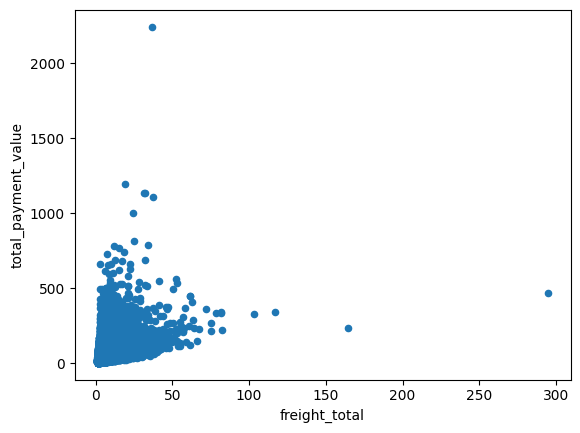

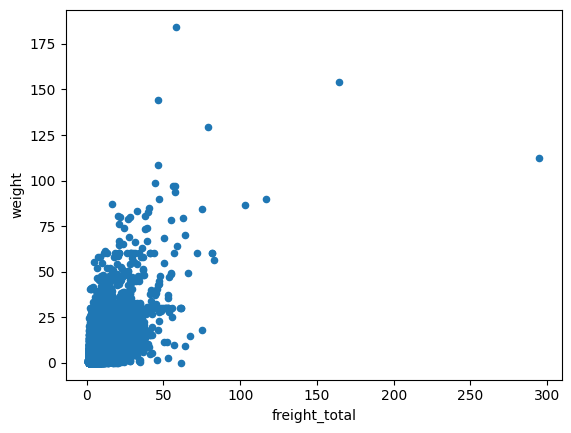

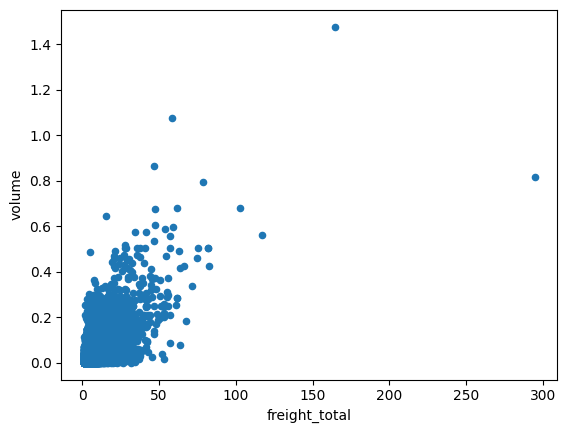

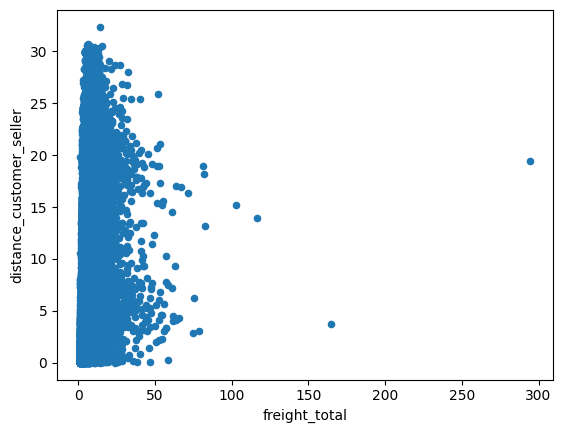

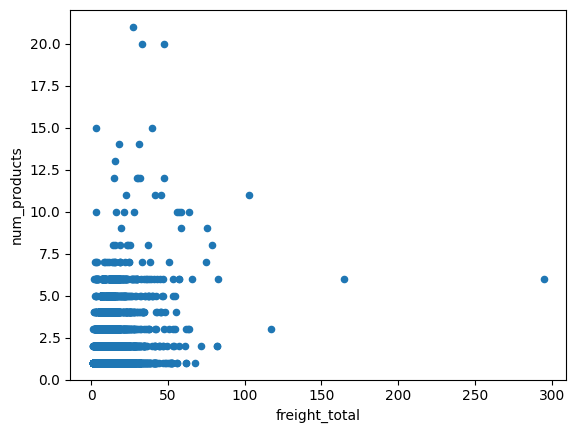

In [810]:
#scarto valori di freight_total ==0
df_global = df_global[df_global['freight_total']>0]
#scarto di weight ==0
df_global = df_global[df_global['weight']>0]
#scarto di volume ==0
df_global = df_global[df_global['volume']>0]
#grafici freight_total vs features

df_global.plot.scatter(x='freight_total', y='total_payment_value')
df_global.plot.scatter(x='freight_total', y='weight')
df_global.plot.scatter(x='freight_total', y='volume')
df_global.plot.scatter(x='freight_total', y='distance_customer_seller')
df_global.plot.scatter(x='freight_total', y='num_products')

<Axes: xlabel='log_freight', ylabel='num_products'>

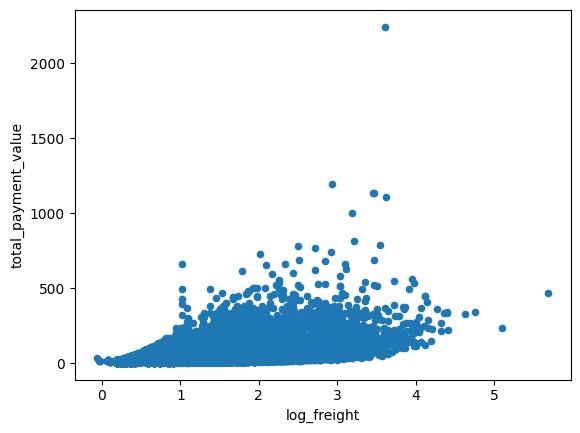

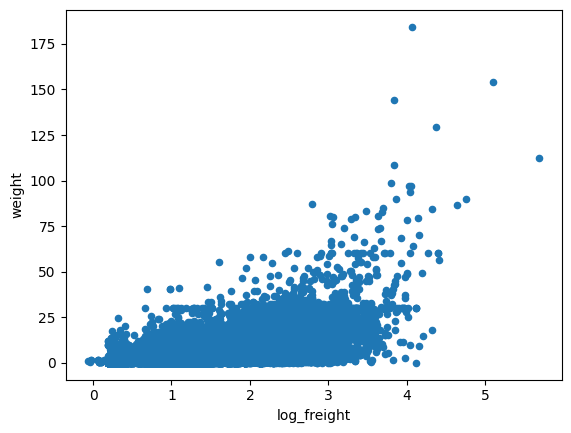

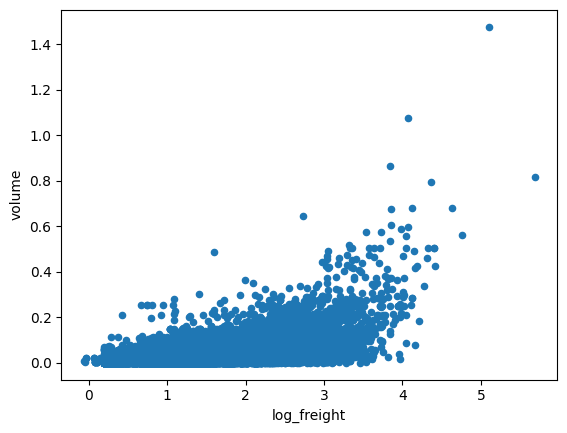

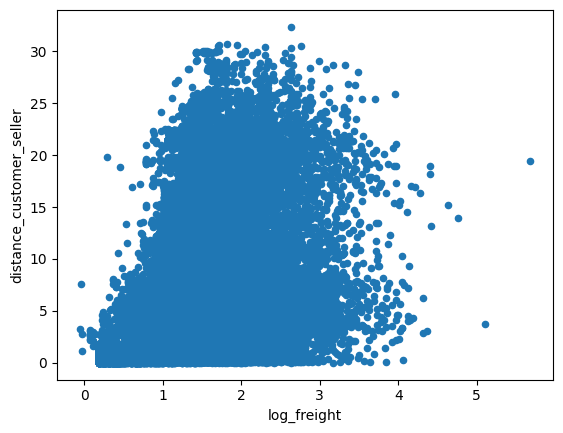

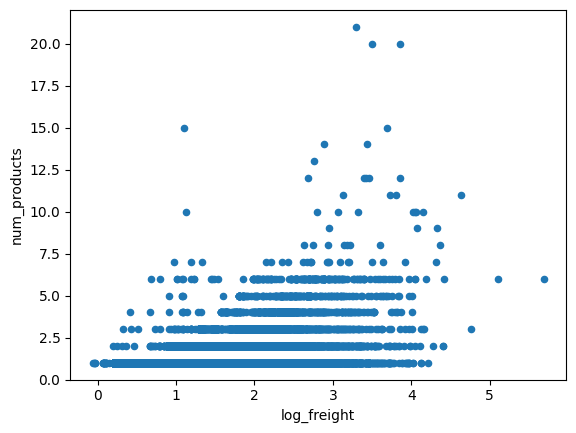

In [811]:
#dato che non si vedono correlazioni significative con freight_total, proviamo con log_freight
df_global['log_freight'] = np.log(df_global['freight_total'])
#grafici log_freight vs features
df_global.plot.scatter(x='log_freight', y='total_payment_value')
df_global.plot.scatter(x='log_freight', y='weight')
df_global.plot.scatter(x='log_freight', y='volume')
df_global.plot.scatter(x='log_freight', y='distance_customer_seller')
df_global.plot.scatter(x='log_freight', y='num_products')

In [817]:
#scartiamo outliers
#scarto freight_total > 120(0.002%)
df_global = df_global[df_global['freight_total']<120]
#scarto total_payment_value > 1000(0.005%)
df_global = df_global[df_global['total_payment_value']<1000]
#scarto valori di volume ==0
df_global = df_global[df_global['volume']>0]
#scarto weight > 125(0.003%)
df_global = df_global[df_global['weight']<125]
#scarto num_prducts > 17(0.003%)
df_global = df_global[df_global['num_products']<17]
#total_payment = log(total_payment_value)
df_global['log_total_payment'] = np.log(df_global['total_payment_value'])
#scartiamo valori di distance_customer_seller = 0(0.49%)
df_global = df_global[df_global['distance_customer_seller']>0]
#non avendo visto una correlazione significativa con distance_customer_seller, proviamo con sqrt(distance_customer_seller)
df_global['sqrt_distance'] = np.sqrt(df_global['distance_customer_seller'])

<Axes: xlabel='log_freight', ylabel='sqrt_distance'>

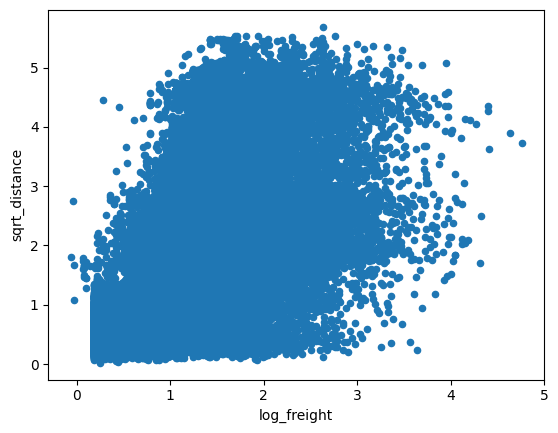

In [818]:
#grafico log_freight e sqrt_distance
df_global.plot.scatter(x='log_freight', y='sqrt_distance')

<Axes: xlabel='log_freight', ylabel='num_products'>

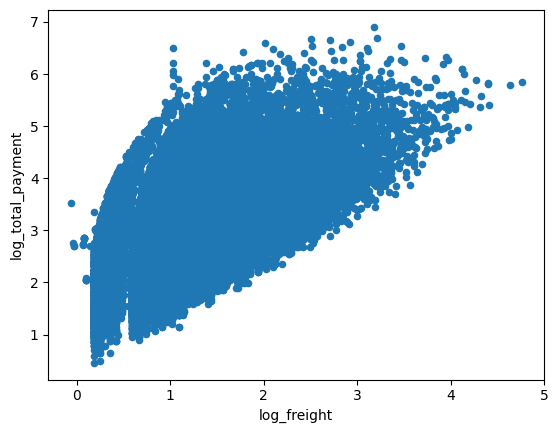

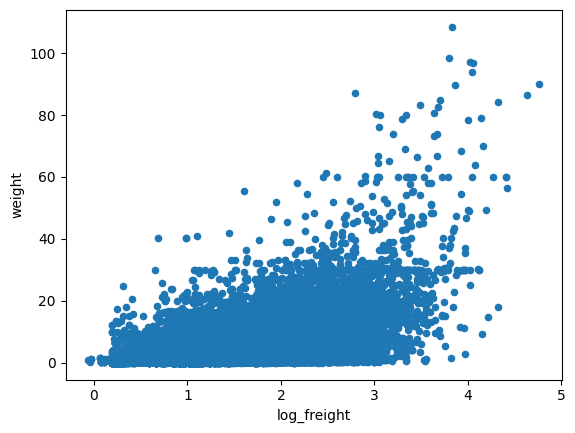

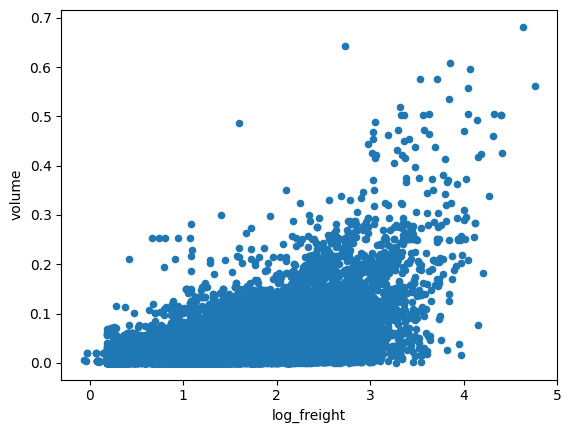

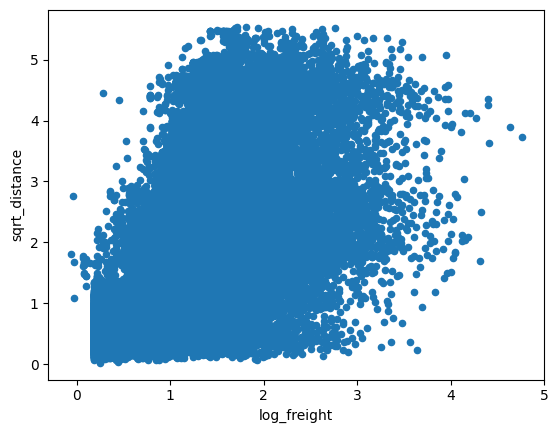

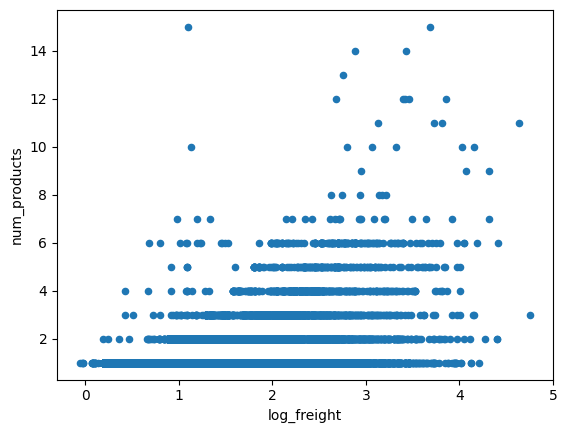

In [844]:
#rivediamo i grafici post pulizia
df_global.plot.scatter(x='log_freight', y='log_total_payment')
df_global.plot.scatter(x='log_freight', y='weight')
df_global.plot.scatter(x='log_freight', y='volume')
df_global.plot.scatter(x='log_freight', y='sqrt_distance')
df_global.plot.scatter(x='log_freight', y='num_products')

In [819]:
#correlazione con freight_total
df_global.corr(numeric_only=True)['log_freight'].sort_values(ascending=False)

log_freight                    1.000000
freight_total                  0.854650
freight_avg                    0.769869
log_total_payment              0.595721
weight                         0.547268
sqrt_distance                  0.535443
volume                         0.523466
distance_customer_seller       0.491409
total_payment_value            0.473695
num_products                   0.416321
total_items                    0.416321
total_price                    0.409392
geolocation_zip_code_prefix    0.324641
customer_lat                   0.307300
actual_delivery_days           0.272390
payment_installments           0.258224
num_sellers                    0.156114
customer_lng                   0.105414
num_categories                 0.095005
seller_lat                     0.064891
num_reviews                   -0.001993
seller_lng                    -0.040537
delivery_delay_days           -0.092562
avg_review                    -0.105847
Name: log_freight, dtype: float64

In [850]:
#drop nulli
df_global = df_global.dropna(axis=0)
Y = df_global['log_freight']
X = df_global[['weight', 'volume', 'sqrt_distance','log_total_payment', 'num_products']]
X = sm.add_constant(data=X)   # add a constant to the model
print(X)
model_mr = sm.OLS(endog=Y,exog=X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
results_mr = model_mr.fit()

                                  const  weight    volume  sqrt_distance  \
order_id                                                                   
00010242fe8c5a6d1ba2dd792cb16214    1.0   0.650  0.003528       1.706438   
00018f77f2f0320c557190d7a144bdd3    1.0  30.000  0.060000       2.348363   
000229ec398224ef6ca0657da4fc703e    1.0   3.050  0.014157       1.692849   
00024acbcdf0a6daa1e931b038114c75    1.0   0.200  0.002400       1.628580   
00042b26cf59d7ce69dfabb4e55b4fd9    1.0   3.750  0.042000       2.513179   
...                                 ...     ...       ...            ...   
fffc94f6ce00a00581880bf54a75a037    1.0  10.150  0.053400       4.980330   
fffcd46ef2263f404302a634eb57f7eb    1.0   8.950  0.044460       1.830780   
fffce4705a9662cd70adb13d4a31832d    1.0   0.967  0.009576       1.800350   
fffe18544ffabc95dfada21779c9644f    1.0   0.100  0.008000       0.812594   
fffe41c64501cc87c801fd61db3f6244    1.0   0.600  0.001710       1.105819   

           

In [851]:
results_mr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_freight   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                 5.613e+04
Date:                gio, 26 feb 2026   Prob (F-statistic):               0.00
Time:                        17:29:29   Log-Likelihood:                -12378.
No. Observations:               93591   AIC:                         2.477e+04
Df Residuals:                   93585   BIC:                         2.482e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.3631      0.004    -91.924      0.000      -0.371      -0.355
weight                0.0319      0.000     91.661      0.000       0.031       0.033
volume                2.2801      0.055     41.391      0.000       2.172       2.388
sqrt_distance         0.2456      0.001    292.445      0.000       0.244       0.247
log_total_payment     0.1892      0.001    146.675      0.000       0.187       0.192
num_products          0.2826      0.002    156.157      0.000       0.279       0.286
==============================================================================
Omnibus:                    17106.122   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           450616.269
Skew:                          -0.114   Prob(JB):                         0.00
Kurtosis:                      13.747   Cond. No.                         354.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [847]:
model = sm.OLS(y_train,X_train)
results = model.fit()
def mae(y, pred): 
    return round(np.mean(np.abs(y - pred)), 2) 
pred_train = results.predict(X_train)

print('Naïve Training MAE:', mae(y_train, np.mean(y_train))) #naive mae
print('Training MAE:', mae(y_train, pred_train)) # mae
pred_test = results.predict(X_test)

print('Naïve Testing MAE:', mae(y_test, np.mean(y_test))) #naive mae
print('Testing MAE:', mae(y_test, pred_test)) # mae

Naïve Training MAE: 0.41
Training MAE: 0.2
Naïve Testing MAE: 0.41
Testing MAE: 0.2


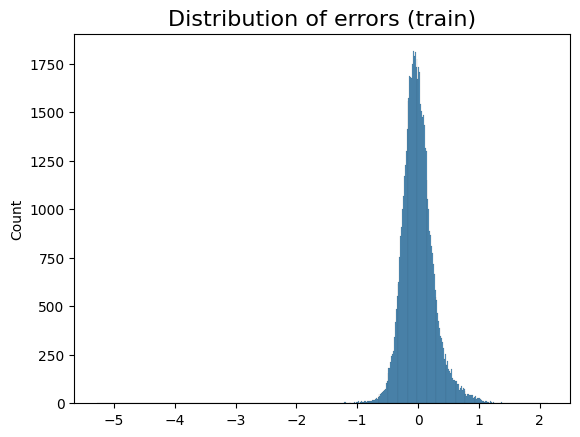

In [848]:
sns.histplot(y_train - pred_train).set_title("Distribution of errors (train)", size=16)
plt.show()

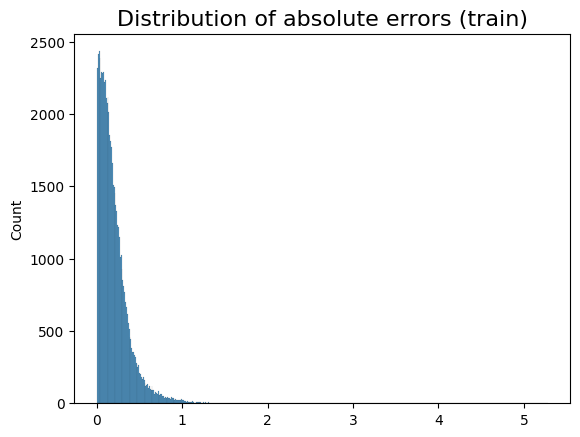

In [849]:
sns.histplot(np.abs(y_train - pred_train)).set_title("Distribution of absolute errors (train)", size=16)
plt.show()

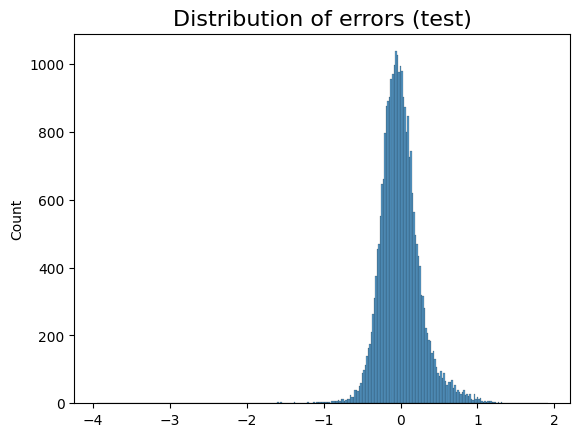

In [842]:
sns.histplot(y_test - pred_test).set_title("Distribution of errors (test)", size=16)
plt.show()

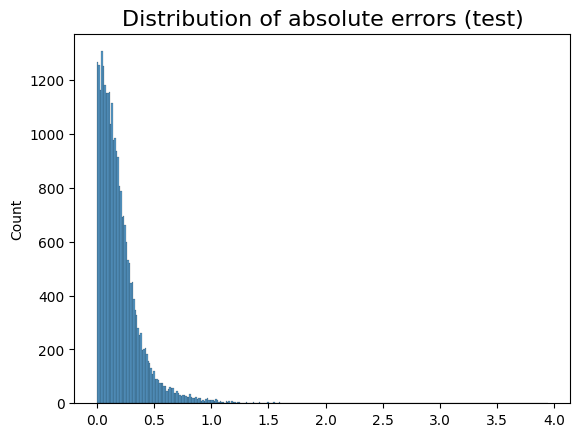

In [843]:
sns.histplot(np.abs(y_test - pred_test)).set_title("Distribution of absolute errors (test)", size=16)
plt.show()